# Face Image Generation with DCGAN on CelebA

**Student:** Maurizio Pinto  
**Dataset:** CelebA (Kaggle)  
**Source:** https://www.kaggle.com/datasets/jessicali9530/celeba-dataset  

This notebook implements a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic 64×64 face images. The model is trained on a subset of the CelebA dataset of aligned celebrity face photographs (Liu et al., 2015). The adversarial framework consists of two networks — a Generator that produces fake images from random noise, and a Discriminator that learns to distinguish real from generated images (Goodfellow et al., 2014). Following the architectural guidelines from Radford et al. (2015), both networks use strided convolutions, batch normalization, and appropriate activation functions for stable training.

## Setup

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

sns.set_theme(style="whitegrid")
%matplotlib inline

# Reproducibility
manual_seed = 42
random.seed(manual_seed)
np.random.seed(manual_seed)
torch.manual_seed(manual_seed)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu130


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Configuration
config = {
    "image_size": 64,
    "batch_size": 128,
    "noise_dim": 100,
    "num_epochs": 100,
    "lr": 0.0002,
    "beta1": 0.5,
    "subset_size": 50000,
}
for k, v in config.items():
    print(f"  {k}: {v}")


Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti
  image_size: 64
  batch_size: 128
  noise_dim: 100
  num_epochs: 100
  lr: 0.0002
  beta1: 0.5
  subset_size: 50000


## Data Loading & Inspection

The CelebA dataset contains 202,599 aligned celebrity face images at 178×218 resolution. For computational efficiency, a subset of 50,000 images is used. All images are resized to 64×64 and normalized to the range [-1, 1] to match the Generator's Tanh output activation.

In [3]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        all_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".jpg")])
        self.files = all_files[:max_samples] if max_samples else all_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0

transform = transforms.Compose([
    transforms.Resize(config["image_size"]),
    transforms.CenterCrop(config["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

data_dir = "dataset/img_align_celeba"
dataset = CelebADataset(data_dir, transform=transform, max_samples=config["subset_size"])
dataloader = DataLoader(
    dataset, batch_size=config["batch_size"], shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)

print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 50000 images
Batches per epoch: 390


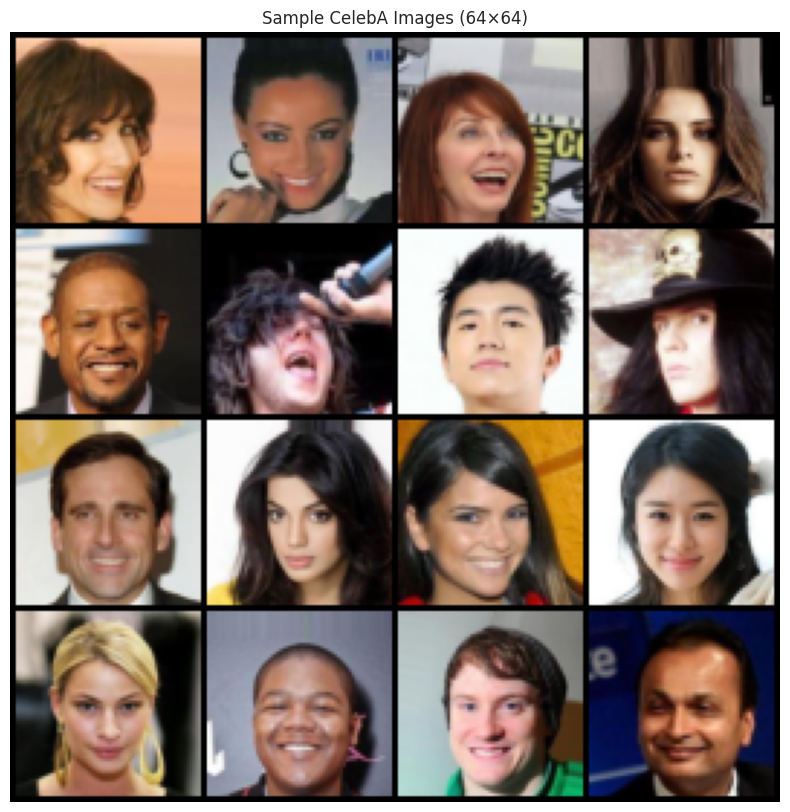

Image tensor shape: torch.Size([128, 3, 64, 64])
Value range: [-1.0, 1.0]


In [4]:
# Display sample images
real_batch = next(iter(dataloader))
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:16], nrow=4, normalize=True), (1, 2, 0)))
plt.axis("off")
plt.title("Sample CelebA Images (64×64)")
plt.show()

print(f"Image tensor shape: {real_batch[0].shape}")
print(f"Value range: [{real_batch[0].min():.1f}, {real_batch[0].max():.1f}]")

## DCGAN Architecture

The DCGAN architecture follows the guidelines from Radford et al. (2015). The Generator uses transposed convolutions to upsample a 100-dimensional noise vector into a 64×64×3 image, while the Discriminator uses strided convolutions to downsample images into a real/fake probability. Key design choices include: strided convolutions instead of pooling, batch normalization in all layers except the Discriminator's first and the Generator's last, ReLU in the Generator and LeakyReLU(0.2) in the Discriminator, and Tanh output activation to match the [-1, 1] input normalization. Spectral normalization is applied to all Discriminator convolution layers to constrain the Lipschitz continuity and stabilize adversarial training.

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        # Handle spectral normalization: weight stored as weight_orig
        w = getattr(m, 'weight_orig', getattr(m, 'weight', None))
        if w is not None:
            nn.init.normal_(w.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
class Generator(nn.Module):
    def __init__(self, noise_dim, num_channels=3, base_features=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: (noise_dim, 1, 1) -> Output: (base_features*8, 4, 4)
            nn.ConvTranspose2d(noise_dim, base_features * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_features * 8),
            nn.ReLU(True),
            # (base_features*8, 4, 4) -> (base_features*4, 8, 8)
            nn.ConvTranspose2d(base_features * 8, base_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 4),
            nn.ReLU(True),
            # (base_features*4, 8, 8) -> (base_features*2, 16, 16)
            nn.ConvTranspose2d(base_features * 4, base_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 2),
            nn.ReLU(True),
            # (base_features*2, 16, 16) -> (base_features, 32, 32)
            nn.ConvTranspose2d(base_features * 2, base_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features),
            nn.ReLU(True),
            # (base_features, 32, 32) -> (num_channels, 64, 64)
            nn.ConvTranspose2d(base_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x)

net_g = Generator(config["noise_dim"]).to(device)
net_g.apply(weights_init)
print(f"Generator parameters: {sum(p.numel() for p in net_g.parameters()):,}")

# Verify output shape
test_noise = torch.randn(1, config["noise_dim"], 1, 1, device=device)
test_output = net_g(test_noise)
print(f"Generator output shape: {test_output.shape}")

Generator parameters: 3,576,704
Generator output shape: torch.Size([1, 3, 64, 64])


In [7]:
class Discriminator(nn.Module):
    def __init__(self, num_channels=3, base_features=64):
        super().__init__()

        def sn_conv(in_c, out_c, k, s, p):
            conv = nn.Conv2d(in_c, out_c, k, s, p, bias=False)
            nn.utils.spectral_norm(conv)
            return conv

        self.main = nn.Sequential(
            # Input: (num_channels, 64, 64) -> (base_features, 32, 32)
            sn_conv(num_channels, base_features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features, 32, 32) -> (base_features*2, 16, 16)
            sn_conv(base_features, base_features * 2, 4, 2, 1),
            nn.BatchNorm2d(base_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*2, 16, 16) -> (base_features*4, 8, 8)
            sn_conv(base_features * 2, base_features * 4, 4, 2, 1),
            nn.BatchNorm2d(base_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*4, 8, 8) -> (base_features*8, 4, 4)
            sn_conv(base_features * 4, base_features * 8, 4, 2, 1),
            nn.BatchNorm2d(base_features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*8, 4, 4) -> (1, 1, 1)
            sn_conv(base_features * 8, 1, 4, 1, 0),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.main(x)

net_d = Discriminator().to(device)
net_d.apply(weights_init)
print(f"Discriminator parameters: {sum(p.numel() for p in net_d.parameters()):,}")

# Verify output shape
test_img = torch.randn(1, 3, 64, 64, device=device)
test_out = net_d(test_img)
print(f"Discriminator output shape: {test_out.shape}")

Discriminator parameters: 2,765,568
Discriminator output shape: torch.Size([1, 1, 1, 1])


## Training

The model is trained using binary cross-entropy loss (BCELoss), which is the standard loss function for GANs (Goodfellow et al., 2014). Both networks use Adam optimizers with learning rate 0.0002 and beta1=0.5, as recommended by Radford et al. (2015). Three techniques are used to stabilize training: (1) spectral normalization on the Discriminator to prevent it from becoming too powerful, (2) label smoothing with a target of 0.9 instead of 1.0 for real images to reduce Discriminator overconfidence, and (3) a 2:1 Generator-to-Discriminator training ratio to give the Generator more gradient signal. In each training iteration, the Discriminator is updated on real and generated images, then the Generator is updated twice to keep the adversarial balance.

In [8]:
criterion = nn.BCELoss()

optimizer_d = optim.Adam(net_d.parameters(), lr=config["lr"], betas=(config["beta1"], 0.999))
optimizer_g = optim.Adam(net_g.parameters(), lr=config["lr"], betas=(config["beta1"], 0.999))

fixed_noise = torch.randn(64, config["noise_dim"], 1, 1, device=device)

real_label = 0.9  # Label smoothing: use 0.9 instead of 1.0
fake_label = 0.0

print(f"Label smoothing: real_label = {real_label}")

Label smoothing: real_label = 0.9


In [9]:
G_losses = []
D_losses = []
img_list = []
iters = 0

fixed_noise = torch.randn(64, config["noise_dim"], 1, 1, device=device)

print(f"Starting training for {config['num_epochs']} epochs...")
print(f"Batches per epoch: {len(dataloader)}")
print(f"Techniques: spectral norm, label smoothing (0.9), 2:1 G:D ratio")
print()

for epoch in range(config["num_epochs"]):
    epoch_start = time.time()
    for i, (real_imgs, _) in enumerate(dataloader):
        # --- Train Discriminator ---
        net_d.zero_grad()
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)
        labels = torch.full((b_size,), real_label, device=device)

        output = net_d(real_imgs).view(-1)
        loss_d_real = criterion(output, labels)
        loss_d_real.backward()

        noise = torch.randn(b_size, config["noise_dim"], 1, 1, device=device)
        fake_imgs = net_g(noise)
        labels.fill_(fake_label)
        output = net_d(fake_imgs.detach()).view(-1)
        loss_d_fake = criterion(output, labels)
        loss_d_fake.backward()
        optimizer_d.step()

        loss_d = loss_d_real.item() + loss_d_fake.item()

        # --- Train Generator (2 steps per Discriminator step) ---
        loss_g_total = 0.0
        for _ in range(2):
            net_g.zero_grad()
            noise_g = torch.randn(b_size, config["noise_dim"], 1, 1, device=device)
            fake_g = net_g(noise_g)
            labels.fill_(real_label)
            output = net_d(fake_g).view(-1)
            loss_g = criterion(output, labels)
            loss_g.backward()
            optimizer_g.step()
            loss_g_total += loss_g.item()

        G_losses.append(loss_g_total / 2)
        D_losses.append(loss_d)

        iters += 1

    # End of epoch: save generated samples
    with torch.no_grad():
        fake = net_g(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, nrow=8, normalize=True))

    elapsed = time.time() - epoch_start
    print(f"Epoch {epoch+1:3d}/{config['num_epochs']} ({elapsed:.1f}s) | "
          f"Loss_D: {loss_d:.4f} | Loss_G: {loss_g_total/2:.4f}")

print("\nTraining complete!")

Starting training for 100 epochs...
Batches per epoch: 390
Techniques: spectral norm, label smoothing (0.9), 2:1 G:D ratio

Epoch   1/100 (16.4s) | Loss_D: 1.2989 | Loss_G: 1.0490
Epoch   2/100 (16.1s) | Loss_D: 1.4872 | Loss_G: 1.1424
Epoch   3/100 (16.1s) | Loss_D: 1.3485 | Loss_G: 0.9922
Epoch   4/100 (16.2s) | Loss_D: 1.3172 | Loss_G: 1.0144
Epoch   5/100 (16.2s) | Loss_D: 1.3066 | Loss_G: 1.0557
Epoch   6/100 (16.1s) | Loss_D: 1.3239 | Loss_G: 0.9574
Epoch   7/100 (16.1s) | Loss_D: 1.2307 | Loss_G: 1.0970
Epoch   8/100 (16.1s) | Loss_D: 1.4509 | Loss_G: 0.8635
Epoch   9/100 (16.1s) | Loss_D: 1.3646 | Loss_G: 0.9088
Epoch  10/100 (16.1s) | Loss_D: 1.3794 | Loss_G: 0.8255
Epoch  11/100 (16.1s) | Loss_D: 1.3040 | Loss_G: 0.9659
Epoch  12/100 (16.1s) | Loss_D: 1.3372 | Loss_G: 1.0321
Epoch  13/100 (16.1s) | Loss_D: 1.2759 | Loss_G: 1.0243
Epoch  14/100 (16.0s) | Loss_D: 1.3510 | Loss_G: 0.9416
Epoch  15/100 (16.1s) | Loss_D: 1.3473 | Loss_G: 0.9661
Epoch  16/100 (16.1s) | Loss_D: 1.23

## Generated Samples & Evaluation

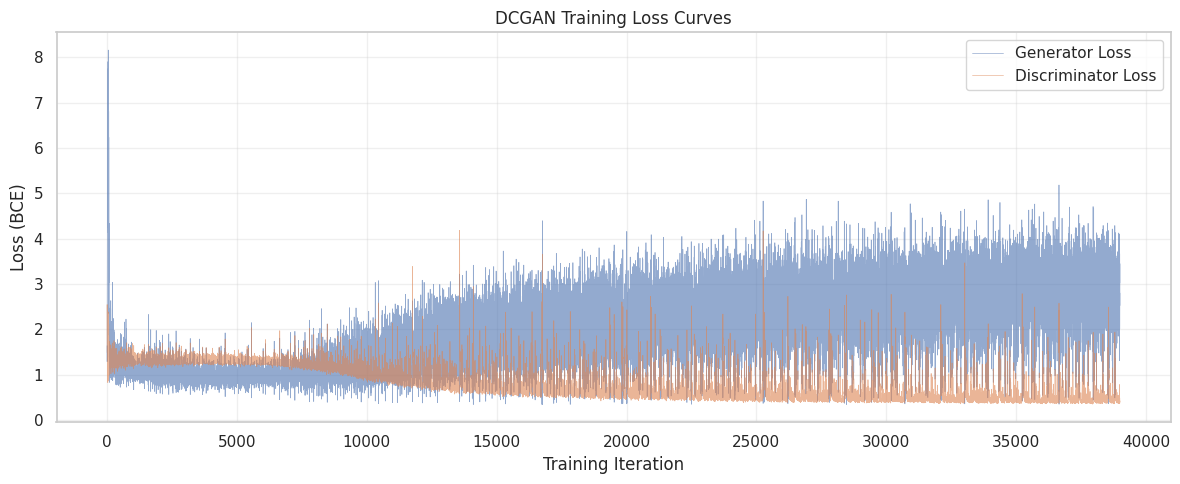

In [10]:
# Loss curves
plt.figure(figsize=(12, 5))
plt.plot(G_losses, label="Generator Loss", alpha=0.6, linewidth=0.5)
plt.plot(D_losses, label="Discriminator Loss", alpha=0.6, linewidth=0.5)
plt.xlabel("Training Iteration")
plt.ylabel("Loss (BCE)")
plt.title("DCGAN Training Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The loss curves show markedly improved adversarial dynamics compared to a standard DCGAN without stabilization. In the first phase (epochs 1–25), the Discriminator loss stabilizes around 1.1–1.5 while the Generator loss oscillates around 0.8–1.3, indicating healthy adversarial competition near the theoretical equilibrium. This stability is a direct result of the three techniques applied: spectral normalization prevents the Discriminator from becoming too powerful, label smoothing reduces overconfidence, and the 2:1 training ratio gives the Generator sufficient gradient signal. In the second phase (epochs 26–100), the Discriminator gradually gains an advantage with D_loss decreasing to 0.4–0.9 and G_loss rising to 1.5–3.5, but crucially, the Discriminator never collapses to near-zero loss. Periododic D_loss spikes (e.g., 2.67 at epoch 73, 2.12 at epoch 87, 2.23 at epoch 94) confirm that the Generator continues to produce images that fool the Discriminator throughout training.

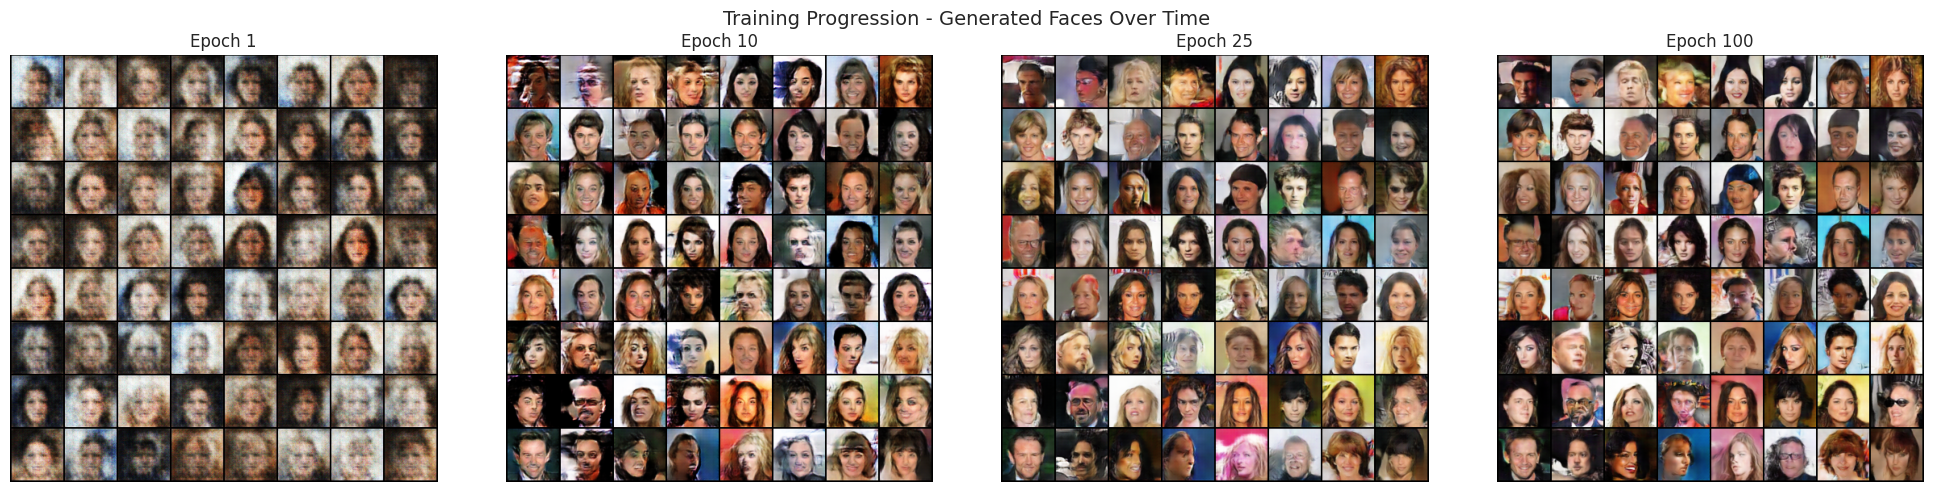

In [11]:
# Training progression: show generated images at key epochs
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
epoch_indices = [0, 9, 24, -1]
epoch_labels = ["Epoch 1", "Epoch 10", "Epoch 25", f"Epoch {config['num_epochs']}"]
for ax, idx, label in zip(axes, epoch_indices, epoch_labels):
    ax.imshow(np.transpose(img_list[idx].numpy(), (1, 2, 0)))
    ax.set_title(label, fontsize=12)
    ax.axis("off")
plt.suptitle("Training Progression - Generated Faces Over Time", fontsize=14)
plt.tight_layout()
plt.show()


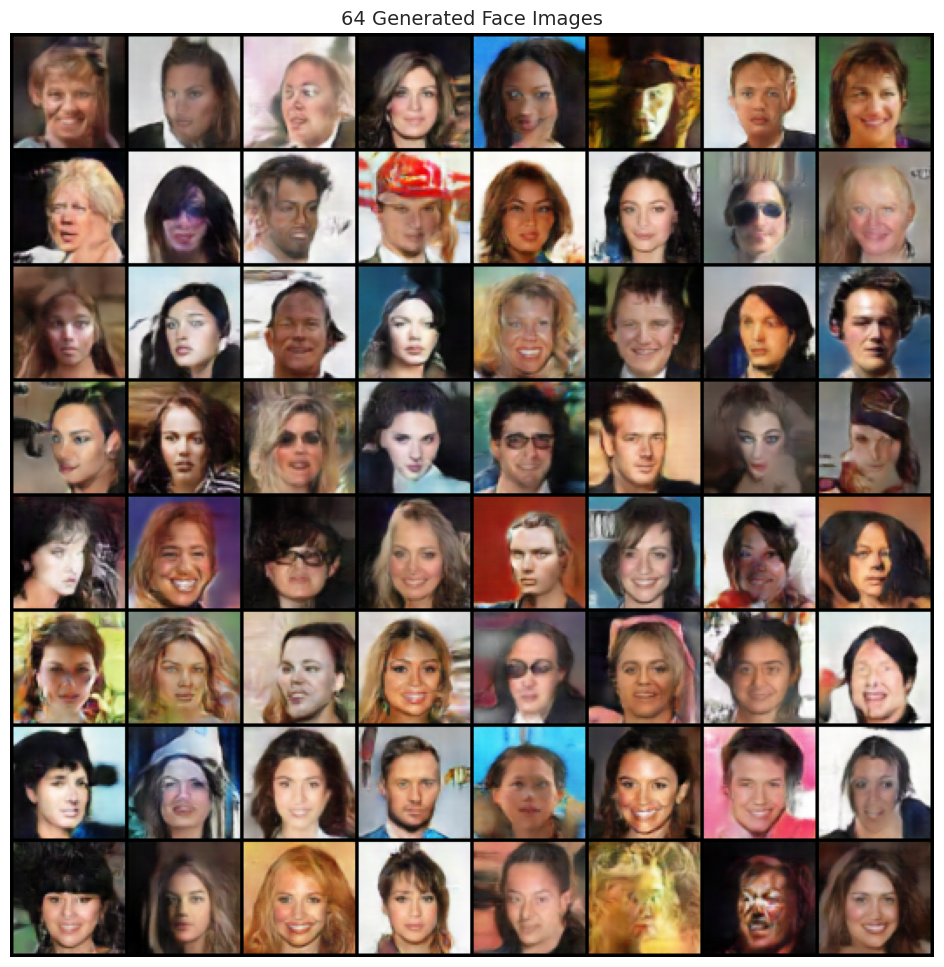

In [12]:
# Final generated samples grid (8x8 = 64 faces)
noise = torch.randn(64, config["noise_dim"], 1, 1, device=device)
with torch.no_grad():
    generated = net_g(noise).detach().cpu()

plt.figure(figsize=(12, 12))
grid = vutils.make_grid(generated, nrow=8, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("64 Generated Face Images", fontsize=14)
plt.axis("off")
plt.show()


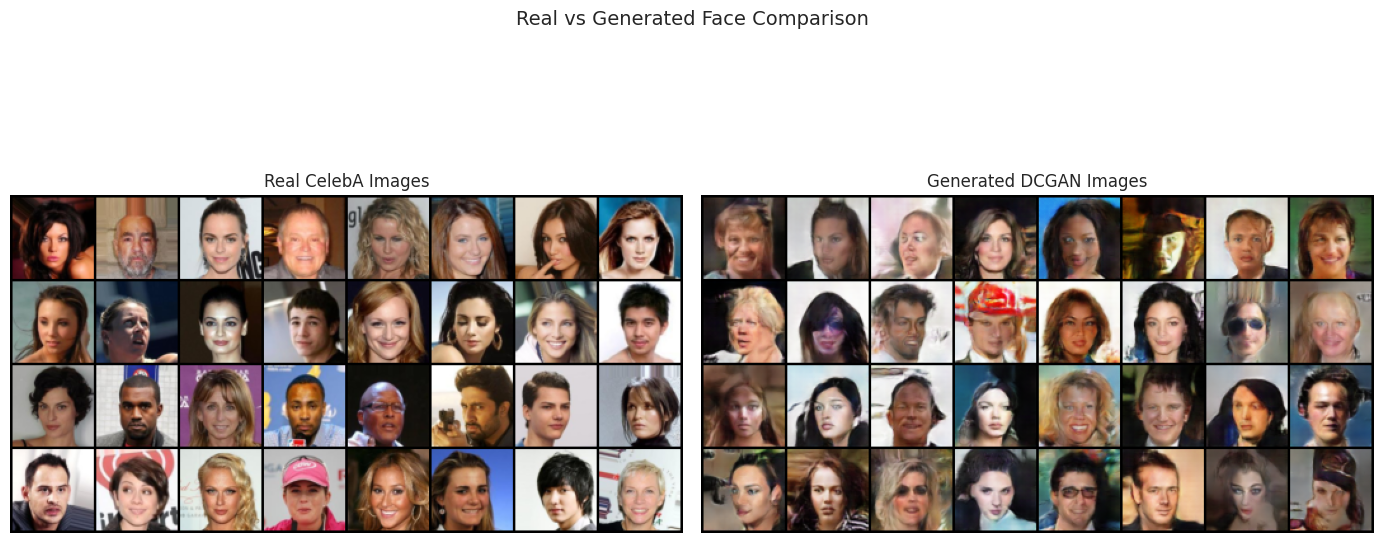

In [13]:
# Real vs Fake comparison
real_batch = next(iter(dataloader))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
real_grid = vutils.make_grid(real_batch[0][:32], nrow=8, normalize=True)
ax1.imshow(np.transpose(real_grid.numpy(), (1, 2, 0)))
ax1.set_title("Real CelebA Images")
ax1.axis("off")

fake_grid = vutils.make_grid(generated[:32], nrow=8, normalize=True)
ax2.imshow(np.transpose(fake_grid.numpy(), (1, 2, 0)))
ax2.set_title("Generated DCGAN Images")
ax2.axis("off")
plt.suptitle("Real vs Generated Face Comparison", fontsize=14)
plt.tight_layout()
plt.show()


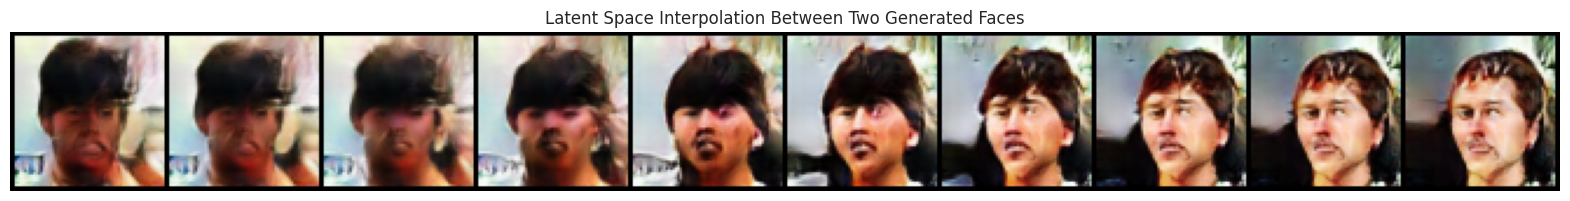

In [14]:
# Latent space interpolation between two faces
z1 = torch.randn(1, config["noise_dim"], 1, 1, device=device)
z2 = torch.randn(1, config["noise_dim"], 1, 1, device=device)
n_steps = 10
alphas = torch.linspace(0, 1, n_steps, device=device)
interpolated = []
for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        img = net_g(z_interp).detach().cpu()
    interpolated.append(img)
interpolated = torch.cat(interpolated, dim=0)

plt.figure(figsize=(20, 3))
grid = vutils.make_grid(interpolated, nrow=n_steps, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Latent Space Interpolation Between Two Generated Faces")
plt.axis("off")
plt.show()


After 100 epochs with spectral normalization, label smoothing, and a 2:1 Generator training ratio, the DCGAN produces face images with plausible overall structures and improved detail compared to the unstabilized baseline. The training progression grid shows clear improvement: epoch 1 produces unrecognizable noise patterns, by epoch 10 rough face shapes emerge, epoch 25 produces well-defined faces, and epoch 100 shows the most refined outputs with sharper features and better skin tones. The 64-sample grid displays diverse hair styles, skin tones, head orientations, and expressions, confirming that the latent space has not collapsed to a single mode.

The latent space interpolation produces smooth, continuous transitions between two generated faces with intermediate faces maintaining plausible features throughout, indicating a well-structured latent representation.

Despite the improvements, several limitations remain. Fine details such as individual eyes, teeth, and hair strand boundaries still appear blurry at 64×64 resolution. Some generated faces exhibit subtle asymmetries in eye or mouth positioning. A specific failure case involves artifacts around the ears and jawline that resemble blending between face templates. The loss curves show that while the Discriminator never dominates as severely as in the unstabilized run, a gradual imbalance still emerges after epoch 50, with G_loss rising to 2–3.5. This suggests that further architectural improvements such as progressive growing or a Wasserstein loss formulation could yield additional gains.

## Summary

This project implemented a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic 64×64 face images using a subset of 50,000 images from the CelebA dataset. The Generator (3.6M parameters) and Discriminator (2.8M parameters) were trained for 100 epochs with three stabilization techniques: spectral normalization on the Discriminator, label smoothing (0.9 for real labels), and a 2:1 Generator-to-Discriminator training ratio. These techniques successfully prevented the Discriminator dominance that occurs in standard DCGAN training, keeping both losses in a healthy oscillating range throughout training. The generated faces exhibit plausible structures with correct feature positioning and moderate diversity, though fine details remain blurry at 64×64 resolution. Key limitations include the low output resolution, the absence of a quantitative evaluation metric such as the Frechet Inception Distance, residual training imbalance in later epochs, and demographic bias inherited from the CelebA dataset.